In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Shape:", df.shape)
print("\nColumn info:")
df.info()

Shape: (891, 12)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
data_dict = pd.DataFrame({
    'dtype': df.dtypes,
    'percent_missing': (df.isnull().sum() / len(df) * 100).round(2),
    'cardinality': df.nunique(),
    'range_or_examples': [
        f"{df[col].min()} to {df[col].max()}" if df[col].dtype in ['int64', 'float64']
        else f"{df[col].unique()[:5]}"
        for col in df.columns
    ]
})
data_dict

,dtype,percent_missing,cardinality,range_or_examples
PassengerId,int64,0.00,891,1 to 891
Survived,int64,0.00,2,0 to 1
Pclass,int64,0.00,3,1 to 3
Name,str,0.00,891,<StringArray>\n[ 'B...
Sex,str,0.00,2,"<StringArray>\n['male', 'female']\nLength: 2, ..."
Age,float64,19.87,88,0.42 to 80.0
SibSp,int64,0.00,7,0 to 8
Parch,int64,0.00,7,0 to 6
Ticket,str,0.00,681,"<StringArray>\n['A/5 21171', 'PC 17599', 'STON..."
Fare,float64,0.00,248,0.0 to 512.3292


In [4]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


In [5]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [6]:
# Age: numeric, moderate missing -> impute with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Cabin: too many missing (~77%) -> drop column
df = df.drop(columns=['Cabin'])

# Embarked: very few missing -> impute with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [7]:
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')
df.dtypes

PassengerId       int64
Survived       category
Pclass         category
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Embarked       category
dtype: object

In [10]:
df['Sex'] = df['Sex'].str.lower().str.strip()
df['Embarked'] = df['Embarked'].str.upper().str.strip()

## Missing Value Strategy

- **Age** (~20% missing): Imputed with median, since age is 
  roughly numeric and median is robust to outliers.
- **Cabin** (~77% missing): Dropped entirely — too much missing 
  data to reliably impute or use.
- **Embarked** (~0.2% missing): Imputed with mode, since only 
  2 rows were affected.

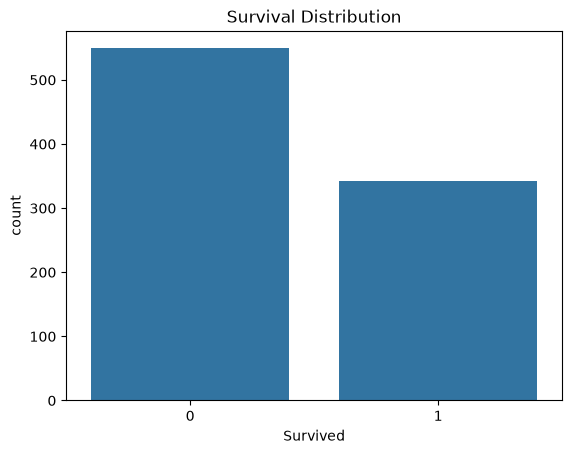

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [11]:
sns.countplot(data=df, x='Survived')
plt.title('Survival Distribution')
plt.show()

print(df['Survived'].value_counts(normalize=True))

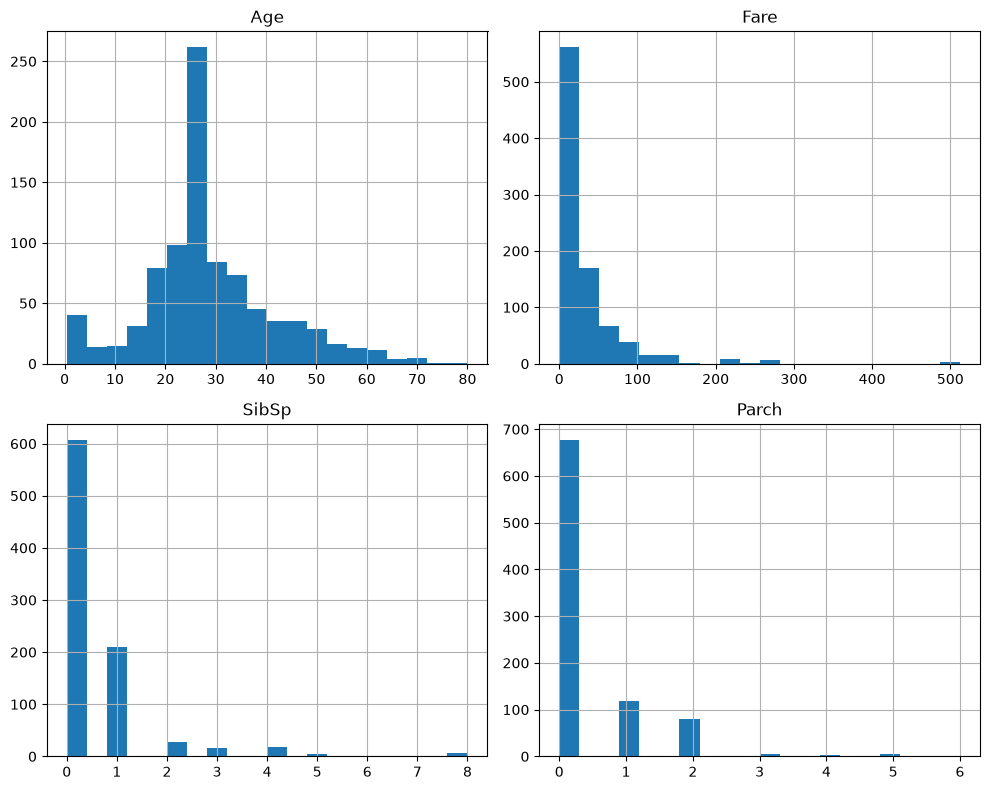

In [12]:
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df[numeric_cols].hist(bins=20, figsize=(10, 8))
plt.tight_layout()
plt.show()

In [13]:
categorical_cols = ['Pclass', 'Sex', 'Embarked']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Embarked:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


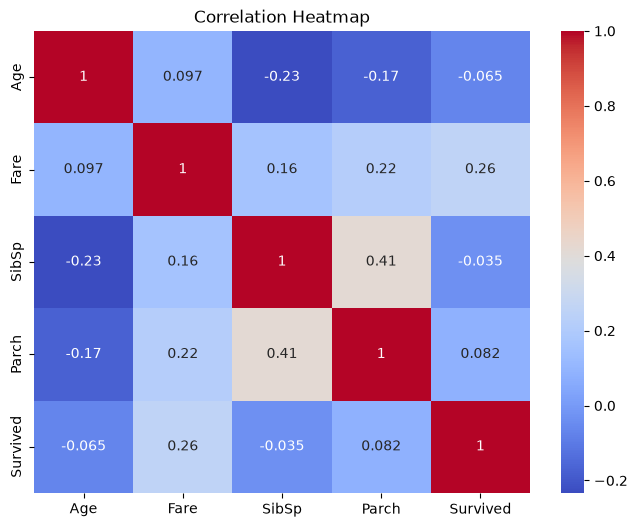

In [14]:
plt.figure(figsize=(8, 6))
numeric_df = df[['Age', 'Fare', 'SibSp', 'Parch']].copy()
numeric_df['Survived'] = df['Survived'].astype(int)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
for col in ['Pclass', 'Sex', 'Embarked']:
    print(f"\nSurvival rate by {col}:")
    print(df.groupby(col, observed=True)['Survived'].apply(lambda x: (x.astype(int) == 1).mean()))


Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


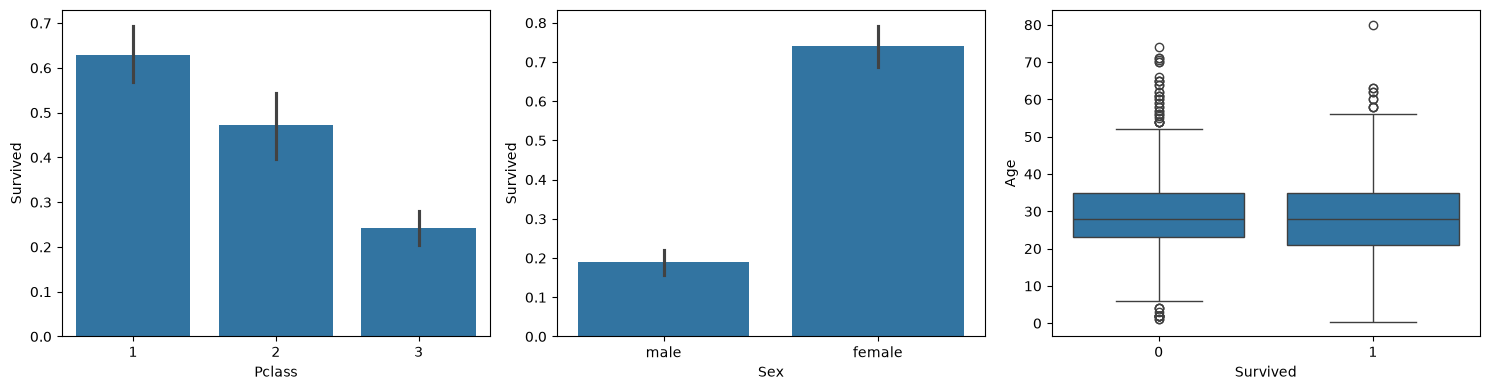

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=df, x='Pclass', y=df['Survived'].astype(int), ax=axes[0])
sns.barplot(data=df, x='Sex', y=df['Survived'].astype(int), ax=axes[1])
sns.boxplot(data=df, x='Survived', y='Age', ax=axes[2])
plt.tight_layout()
plt.show()

## Key Observations

1. **Survival rate is imbalanced** — only about 38% of passengers 
   survived. This implies we may need to consider class imbalance 
   techniques (like class weights) when modelling.

2. **Sex is the strongest predictor** — women survived at 74.2% 
   compared to only 18.9% for men. This suggests Sex should be a 
   top feature in any model.

3. **Passenger class strongly affects survival** — 1st class 
   passengers survived at ~63%, while 3rd class only survived at 
   ~24%. This implies Pclass captures socioeconomic access to 
   lifeboats.

4. **Age shows some relationship with survival** — the boxplot 
   shows survivors skew slightly younger, with more high-age 
   outliers among non-survivors. This suggests age-based feature 
   engineering (e.g., "is_child") could help.

5. **Embarkation port correlates with survival** — passengers who 
   boarded at Cherbourg (C) survived at the highest rate (55%), 
   likely because more 1st class passengers boarded there. This 
   implies Embarked may be a proxy for Pclass, not an independent 
   effect.

In [17]:
df.to_csv('../data/processed/titanic_cleaned.csv', index=False)
print("Saved cleaned data.")

Saved cleaned data.
